In [1]:
import os
import numpy as np
import scipy as sp

import torch as pt
from torch import nn as nn

import pickle

%matplotlib widget
from matplotlib import pyplot as plt
import matplotlib as mpl
import matplotlib.tri as mtri
from scipy.interpolate import griddata, LinearNDInterpolator


In [2]:
from utils.aggregation import aggregate_seeded_results


## Notebook roadmap
This notebook reproduces **Figure 5** from the main manuscript (extended toric-code experiments).

Figure intent:
- map correlation-regime structure across lattice/basis settings,
- compare the standard phase-map panels (a, b, c, e, f),
- overlay a Widom-line-style panel (d),
- and show the summed susceptibility panel (g).

Execution flow:
1. Configure global plotting style and cluster colour mapping.
2. Load critical-region data and observables used for Widom-line/susceptibility panels.
3. Aggregate seeded divergence matrices and run HDBSCAN for the critical-region panel.
4. Load and aggregate the full/basic toric-code dataset.
5. Run HDBSCAN for each basis/lattice configuration used in panels (a, b, c, e, f).
6. Build panel (g) from interpolated susceptibility fields.
7. Assemble and export `figure_5.pdf` and `figure_5.svg`.



# Common settings
Set typography, line widths, and plotting defaults used by all panels.


In [3]:
axes_linewidth = 1
tick_size = 8
label_size = 9

# --- ONE-OFF CONFIG -------------------------------------------------
plt.rcParams.update({
    # Tell Matplotlib to ask LaTeX to typeset *all* text
    "text.usetex": True,

    # Let LaTeX pick the fonts (serif is fine because Libertine re-defines it)
    "font.family": "sans-serif",

    # Any extra LaTeX you need goes here – one long raw string *or* a list
    "text.latex.preamble": r"""
        \usepackage[semibold,sfdefault]{libertine}   % serif+sans in one go
        \usepackage[libertine]{newtxmath}    
    """,
    "axes.linewidth": axes_linewidth,
})

### Cluster colour specification
Define a fixed label-to-colour mapping shared by all clustering visualizations.


In [4]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm                   # you already imported this higher up

# ----- colours you picked -----------------------------------------------------
class_to_colour = {
    -1: "black",          # mild grey  (noise / unassigned)
     0: "xkcd:periwinkle",  # blue
     1: "xkcd:peach",      # green
     2: "xkcd:bordeaux",       # bordeaux
     3: 'xkcd:light red',
     4: 'xkcd:purple',      # 
    5: 'xkcd:light blue',  # red
    6: 'xkcd:yellow',  # yellow
    7: 'xkcd:light purple',  # cyan
    8: 'xkcd:magenta',  # magenta
}
# ------------------------------------------------------------------------------
all_labels      = [-1, 0, 1, 2, 3, 4, 5]#, 6, 7, 8,]                                    # only classes you use
colour_list     = [class_to_colour[label] for label in all_labels]

cluster_cmap    = mcolors.ListedColormap(colour_list, name="cluster_cmap")

# half-step boundaries:  …|-1.5|-0.5|0.5|1.5|…
cluster_bounds  = np.arange(len(all_labels) + 1) - 1.5
#              = [-1.5, -0.5, 0.5, 1.5]

cluster_norm    = mcolors.BoundaryNorm(cluster_bounds, cluster_cmap.N)

from matplotlib.cm import ScalarMappable

cluster_mappable = ScalarMappable(cmap=cluster_cmap, norm=cluster_norm)
cluster_mappable.set_array([])       # suppress “no mappable data” warning

# Critical-region data preparation
Prepare inputs for panel (d) and intermediate clustering structures.


## Load critical-region and observable data
Load seeded toric-code distances and precomputed observables needed downstream.


In [5]:
from nestconf import Configurable
from typing import Tuple

class Experiment(Configurable):
    dim: int = None
    lattice_type: int = None
    system_size: int = None
    bases_to_include: Tuple = None


In [6]:
path2figure_data = os.path.join('../data/figures/figure_5/critical_region')
with open(os.path.join(path2figure_data, 'seeded_f_matrices_dict.pickle'), 'rb') as handle:
    widom_seeded_f_matrices_dict = pickle.load(handle)
with open(os.path.join(path2figure_data, 'seeded_f_matrices_std_dict.pickle'), 'rb') as handle:
    widom_seeded_f_matrices_std_dict = pickle.load(handle)
with open(os.path.join(path2figure_data, 'coords_dict.pickle'), 'rb') as handle:
    widom_coords_dict = pickle.load(handle)


In [7]:
suffix = '19_9_2025'
with open(f'../data/figures/figure_5/obs_mean_dict_{suffix}.pickle', 'rb') as handle:
    obs_mean_dict = pickle.load(handle)
with open(f'../data/figures/figure_5/obs_x_field_dict_{suffix}.pickle', 'rb') as handle:
    obs_x_field_dict = pickle.load(handle)
with open(f'../data/figures/figure_5/obs_z_field_dict_{suffix}.pickle', 'rb') as handle:
    obs_z_field_dict = pickle.load(handle)

## Aggregate and cluster critical-region data
Combine seeded outputs and infer cluster labels for the critical-region panel.


### Aggregate seeded matrices
Use `aggregate_seeded_results` to combine seed-level means/uncertainties.


In [8]:
widom_f_matrices_dict = {}
widom_f_matrices_std_dict = {}
for exp_config in widom_seeded_f_matrices_dict:
    widom_f_matrices_dict[exp_config] = {}
    widom_f_matrices_std_dict[exp_config] = {}
    for divergence in widom_seeded_f_matrices_dict[exp_config]:
        f_matrix, f_matrix_std, _, _ = aggregate_seeded_results(
            seeded_f_tensors=list(widom_seeded_f_matrices_dict[exp_config][divergence].values()),
            seeded_std_tensors=list(widom_seeded_f_matrices_std_dict[exp_config][divergence].values()),
            verbose=False,
            use_inverse_variance_weighting=True,
        )
        widom_f_matrices_dict[exp_config][divergence] = f_matrix
        widom_f_matrices_std_dict[exp_config][divergence] = f_matrix_std


### Run HDBSCAN for critical-region panel
Select the target experiment config and infer cluster labels.


In [9]:
from sklearn.cluster import HDBSCAN

widom_candidates = []
for exp_config in widom_f_matrices_dict:
    if exp_config.system_size != 30 or exp_config.learning_rate != 1e-4 or exp_config.hidden_size != 512:
        continue
    if 'hellinger' not in widom_f_matrices_dict[exp_config]:
        continue
    widom_candidates.append(exp_config)

if len(widom_candidates) != 1:
    raise RuntimeError(f'Expected exactly one Widom config, got {len(widom_candidates)}')

widom_exp_config = widom_candidates[0]
widom_distance_matrix = pt.sqrt(widom_f_matrices_dict[widom_exp_config]['hellinger'].clone())
widom_distance_matrix = pt.nan_to_num(widom_distance_matrix, nan=np.sqrt(2.0))

widom_hdbscan = HDBSCAN(metric='precomputed', copy=True, allow_single_cluster=False)
widom_cluster_labels = widom_hdbscan.fit_predict(widom_distance_matrix)
widom_coords = np.asarray([np.asarray(point_coords) for point_coords in widom_coords_dict[widom_exp_config]])


In [10]:
anchor2lambda = {
    'min_x_max_z': lambda tup: (tup[1][0], -tup[1][1]),
    'max_x_min_z': lambda tup: (-tup[1][0], tup[1][1]),
}

anchor2label = {
    'min_x_max_z': 2,
    'max_x_min_z': 1,
}

last_cluster_idx = len(np.unique(widom_cluster_labels)) - 1
for anchor in anchor2lambda:
    sorted_coords = sorted(enumerate(widom_coords), key=anchor2lambda[anchor])
    anchor_idx = sorted_coords[0][0]

    cur_anchor_label = widom_cluster_labels[anchor_idx]
    cur_anchor_cluster_mask = (widom_cluster_labels == cur_anchor_label)

    anchor_conflict_mask = (widom_cluster_labels == anchor2label[anchor])
    if cur_anchor_label == 0:
        widom_cluster_labels[anchor_conflict_mask] = last_cluster_idx
    else:
        widom_cluster_labels[anchor_conflict_mask] = cur_anchor_label
    widom_cluster_labels[cur_anchor_cluster_mask] = anchor2label[anchor]


In [11]:
import matplotlib.tri as mtri

sigma_x_tri = None
sigma_x_X = None
sigma_z_tri = None
sigma_z_Z = None

target_system_size_for_susc = 30
for basis, obs_name in (('x', 'sigma_x_susceptibility'), ('z', 'sigma_z_susceptibility')):
    xs, ys, zs = [], [], []
    for z_x_field_sum in obs_mean_dict[target_system_size_for_susc][basis][obs_name].keys():
        zvals = np.array(obs_mean_dict[target_system_size_for_susc][basis][obs_name][z_x_field_sum])
        xvals = np.array(obs_x_field_dict[target_system_size_for_susc][basis][obs_name][z_x_field_sum])
        yvals = np.array(obs_z_field_dict[target_system_size_for_susc][basis][obs_name][z_x_field_sum])

        n = min(len(zvals), len(xvals))
        xs.append(xvals[:n])
        ys.append(yvals[:n])
        zs.append(zvals[:n])

    X = np.concatenate(xs)
    Y = np.concatenate(ys)
    Z = np.concatenate(zs)
    tri = mtri.Triangulation(X, Y)

    if basis == 'x':
        sigma_x_tri = tri
        sigma_x_X = Z
    elif basis == 'z':
        sigma_z_tri = tri
        sigma_z_Z = Z

if sigma_x_tri is None or sigma_z_tri is None:
    raise RuntimeError('Failed to construct susceptibility triangulations for x/z bases.')


## Main phase-map clustering
Prepare clusters for panels (a, b, c, e, f) using the basic dataset.


In [12]:
from nestconf import Configurable
from typing import Tuple


class Experiment(Configurable):
    dim: int = None
    lattice_type: int = None
    system_size: int = None
    bases_to_include: Tuple = None
    x_z_field_sum: float = None

path2figure_data = os.path.join('../data/figures/figure_5/main_distance_matrices')
with open(os.path.join(path2figure_data, 'seeded_f_matrices_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_dict = pickle.load(handle)
with open(os.path.join(path2figure_data, 'seeded_f_matrices_std_dict.pickle'), 'rb') as handle:
    seeded_f_matrices_std_dict = pickle.load(handle)
with open(os.path.join(path2figure_data, 'coords_dict.pickle'), 'rb') as handle:
    coords_dict = pickle.load(handle)

f_matrices_dict = {}
f_matrices_std_dict = {}
for exp_config in seeded_f_matrices_dict:
    f_matrices_dict[exp_config] = {}
    f_matrices_std_dict[exp_config] = {}
    for divergence in seeded_f_matrices_dict[exp_config]:
        f_matrix, f_matrix_std, _, _ = aggregate_seeded_results(
            seeded_f_tensors=list(seeded_f_matrices_dict[exp_config][divergence].values()),
            seeded_std_tensors=list(seeded_f_matrices_std_dict[exp_config][divergence].values()),
            verbose=False,
            use_inverse_variance_weighting=False,
        )
        f_matrices_dict[exp_config][divergence] = f_matrix
        f_matrices_std_dict[exp_config][divergence] = f_matrix_std


In [13]:
bases_to_include_list = tuple((('z',), ('x',), ('x', 'z')))

anchor2lambda = {
    'min_x_min_z': lambda tup: (tup[1][0], tup[1][1]),
    'min_x_max_z': lambda tup: (tup[1][0], -tup[1][1]),
    'max_x_min_z': lambda tup: (-tup[1][0], tup[1][1]),
}

anchor2label = {
    'min_x_min_z': 0,
    'min_x_max_z': 1,
    'max_x_min_z': 2,
}

In [14]:
from sklearn.cluster import HDBSCAN

ready_cluster_labels = {}
ready_cluster_x_coords = {}
ready_cluster_z_coords = {}

dim2system_size = {2: 10, 3: 6}

for bases_to_include in bases_to_include_list:
    for lattice_type, dim in (('cubic', 2), ('triangular', 2), ('cubic', 3)):
        for exp_config in f_matrices_dict:
            if ((exp_config.lattice_type != lattice_type)
                or (exp_config.dim != dim)
                or (exp_config.bases_to_include != bases_to_include)
                or (exp_config.system_size != dim2system_size[dim])
                or (exp_config.hidden_size != 256)):
                continue

            coords = np.asarray(coords_dict[exp_config])
            distance_matrix = pt.sqrt(f_matrices_dict[exp_config]['hellinger'].clone())

            hdbscan_model = HDBSCAN(metric='precomputed', copy=True)
            cluster_labels = hdbscan_model.fit_predict(distance_matrix)

            for anchor in anchor2lambda:
                sorted_coords = sorted(enumerate(coords), key=anchor2lambda[anchor])
                anchor_idx = sorted_coords[0][0]

                cur_anchor_label = cluster_labels[anchor_idx]
                cur_anchor_cluster_mask = (cluster_labels == cur_anchor_label)

                anchor_conflict_mask = (cluster_labels == anchor2label[anchor])
                cluster_labels[anchor_conflict_mask] = cur_anchor_label
                cluster_labels[cur_anchor_cluster_mask] = anchor2label[anchor]

            ready_cluster_labels[(bases_to_include, lattice_type, dim)] = cluster_labels
            ready_cluster_x_coords[(bases_to_include, lattice_type, dim)] = coords[:, 0]
            ready_cluster_z_coords[(bases_to_include, lattice_type, dim)] = coords[:, 1]


# Build and export figure
Assemble all manuscript panels and export publication files.


In [15]:
from matplotlib.ticker import AutoMinorLocator, FuncFormatter

def compact_axes(ax,
                 x_tex=None,
                 y_tex=None,
                 bottom_only=False,   # set True for matshow panels
                 ):
    # -------- X axis --------
    xmin, xmax = ax.get_xlim()
    xmid = 0.5 * (xmin + xmax)

    # ticks at: first, middle (for symbol), (drop the last numeric label)
    ax.xaxis.set_ticks([xmin, xmid, xmax])
    ax.xaxis.set_major_formatter(FuncFormatter(
        lambda v, p: (
            f"{v:g}" if np.isclose(v, xmin) or np.isclose(v, xmax) else (x_tex or "")
        )
    ))
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='x', which='major',
                   labelsize=label_size,
                   direction='in', bottom=True, top=False, length=4, pad=1)
    ax.tick_params(axis='x', which='minor',
                   labelsize=label_size,
                   direction='in', bottom=True, top=False, length=3, pad=1)
    ax.set_xlabel(None)                      # free margin
    if bottom_only:                          # ensure bottom only
        ax.tick_params(axis='x', 
                   labelsize=label_size,labelbottom=True, labeltop=False)
        ax.xaxis.set_label_position('bottom')

    # -------- Y axis --------
    ymin, ymax = ax.get_ylim()
    ymid = 0.5 * (ymin + ymax)

    ax.yaxis.set_ticks([ymin, ymid, ymax])
    ax.yaxis.set_major_formatter(FuncFormatter(
        lambda v, p: (
            f"{v:g}" if np.isclose(v, ymin) or np.isclose(v, ymax)
            else (y_tex or "")
        )
    ))
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    ax.tick_params(axis='y', which='major',
                   labelsize=label_size,
                   direction='in', left=True, right=True, length=4, pad=1)
    ax.tick_params(axis='y', which='minor',
                   labelsize=label_size,
                   direction='in', left=True, right=True, length=3, pad=1)
    ax.set_ylabel(None)


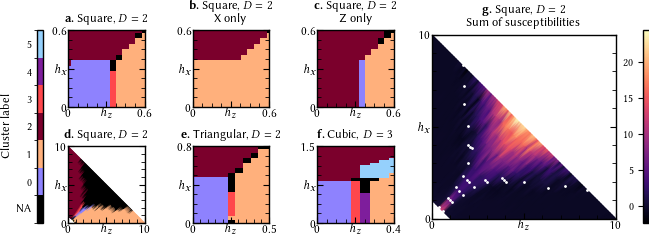

In [16]:
fig_width_cm = 16.5
fig_height_cm = 6
cm2inches = 1 / 2.54
def figsize_cm2inches(fig_width_cm, fig_height_cm):
    return (fig_width_cm * cm2inches, fig_height_cm * cm2inches)

# Specifying the figure layout
fig = plt.figure(figsize=figsize_cm2inches(fig_width_cm, fig_height_cm),
                constrained_layout=True)
grid_spec = fig.add_gridspec(nrows=2, 
                             ncols=7,                           
                             width_ratios=[0.05, 1, 1, 1, 0.75, 0.75, 0.05])
fig.set_constrained_layout_pads(w_pad=0.00, h_pad=0.0)

small_axes = {}
for row_idx in range(2):
    for col_idx in range(4):
        if col_idx in (0,  ): 
            continue
        small_axes[(row_idx, col_idx)] = fig.add_subplot(grid_spec[row_idx, col_idx])

susc_ax = fig.add_subplot(grid_spec[:, 4:6])


label_sets_of_interest2ax_idx = {(('x', 'z',), 'cubic', 2): (0, 0),
                                   (('x', 'z',), 'triangular', 2): (1, 1),
                                   (('x', 'z',), 'cubic', 3): (1, 2),
                                   (('x',), 'cubic', 2): (0, 1),
                                   (('z',), 'cubic', 2): (0, 2)}
label_set_descr2title = {
    (('x', 'z',), 'cubic', 2): '$\\textbf{a.}$ Square, $D = 2$',
    (('x',), 'cubic', 2): '$\\textbf{b.}$ Square, $D = 2$\n X only',
    (('z',), 'cubic', 2): '$\\textbf{c.}$ Square, $D = 2$\n Z only',
    (('x', 'z',), 'triangular', 2): '$\\textbf{e.}$ Triangular, $D = 2$',
    (('x', 'z',), 'cubic', 3): '$\\textbf{f.}$ Cubic, $D = 3$',
}
for label_set_idx, label_set_descr in enumerate(list(label_sets_of_interest2ax_idx.keys())):
    row_idx, col_idx = label_sets_of_interest2ax_idx[label_set_descr]
    cur_ax = small_axes[(row_idx, col_idx + 1)]
    bases_to_include, lattice_type, dim = label_set_descr
    cluster_labels = ready_cluster_labels[label_set_descr]
    x_fields = ready_cluster_x_coords[label_set_descr]
    z_fields = ready_cluster_z_coords[label_set_descr]
    #cur_ax.set_title(f'{lattice_type}, dim = {dim}', fontsize=label_size)
    cur_ax.set_title(label_set_descr2title[label_set_descr], fontsize=label_size)
    X, Y = x_fields, z_fields
    L = cluster_labels
    xi = np.linspace(X.min(), X.max(), 200)
    yi = np.linspace(Y.min(), Y.max(), 200)
    Xi, Yi = np.meshgrid(xi, yi)

    Li = griddata((X, Y), L, (Xi, Yi), method='nearest')   # nearest keeps labels

    cur_ax.matshow(Li.T, 
                  origin='lower', 
                  extent=[Y.min(), Y.max(), X.min(), X.max()],
                  cmap=cluster_cmap, 
                  norm=cluster_norm, 
                  interpolation='nearest', 
                  aspect=1 / ((X.max() - X.min()) / (Y.max() - Y.min())))

    cur_ax.set_xlabel(r'$h_z$', fontsize=label_size)
    cur_ax.set_ylabel(r'$h_x$', fontsize=label_size)


# Add Widom line data
widom_ax = small_axes[1, 1]
widom_ax.set_title('$\\textbf{d.}$ Square, $D = 2$', fontsize=label_size)
widom_ax.tripcolor(widom_coords[:, 0],
             widom_coords[:, 1],
             widom_cluster_labels,
            norm=cluster_norm,
            cmap=cluster_cmap,
            shading='gouraud')

widom_ax.set_aspect('equal')
widom_ax.set_xlim((0, 10))
widom_ax.set_ylim((0, 10))
widom_ax.set_xlabel(r'$h_z$', fontsize=label_size)
widom_ax.set_ylabel(r'$h_x$', fontsize=label_size)

# Add susceptibilities

sus_vmin = float(np.nanmin([np.nanmin(sigma_x_X), np.nanmin(sigma_z_Z)]))
sus_vmax = float(np.nanmax([np.nanmax(sigma_x_X), np.nanmax(sigma_z_Z)]))
sus_norm = mpl.colors.Normalize(vmin=sus_vmin, vmax=sus_vmax)
sus_cmap = 'magma'


# Points & values
x1, y1 = sigma_x_tri.x, sigma_x_tri.y
x2, y2 = sigma_z_tri.x, sigma_z_tri.y

P_union = np.vstack([np.c_[x1, y1], np.c_[x2, y2]])
xu, yu = P_union[:, 0], P_union[:, 1]

# Interpolators
f_x = LinearNDInterpolator(np.c_[x1, y1], sigma_x_X)
f_z = LinearNDInterpolator(np.c_[x2, y2], sigma_z_Z)

# Evaluate both on the union
sx = f_x(P_union)     # may contain NaNs outside sigma_x hull
sz = f_z(P_union)     # may contain NaNs outside sigma_z hull

# Outside a basis-specific convex hull, treat the missing contribution as zero
# so the summed field remains defined all the way to the sampled domain edge.
sx_filled = np.nan_to_num(sx, nan=0.0)
sz_filled = np.nan_to_num(sz, nan=0.0)
s_tot = sx_filled + sz_filled

# Common triangulation on the union of sampled susceptibility points
tri_u = mtri.Triangulation(xu, yu)

t = susc_ax.tripcolor(
    tri_u,
    s_tot,
    cmap=sus_cmap,
    shading='gouraud',
    edgecolors='none',
    linewidth=0,
    antialiased=True
)
boundary_mask = (widom_cluster_labels[1:] != widom_cluster_labels[:-1])
edge_mask = (widom_coords[:, 0] == 0) | (widom_coords[:, 1] == 0)
boundary_mask = boundary_mask & (~edge_mask[1:]) & (~edge_mask[:-1])
boundary_coords = 0.5 * (widom_coords[1:] + widom_coords[:-1])[boundary_mask]
susc_ax.scatter(boundary_coords[:, 0],
             boundary_coords[:, 1],
             s=1,
             c='white',)

susc_ax.set_aspect('equal', adjustable='box')
susc_ax.set_title('$\\textbf{g.}$ Square, $D = 2$ \n Sum of susceptibilities', fontsize=label_size)
susc_ax.set_xlabel(r'$h_z$', fontsize=label_size)
susc_ax.set_ylabel(r'$h_x$', fontsize=label_size)
susc_ax.set_xlim((0, 10))
susc_ax.set_ylim((0, 10))

cbar_ax = fig.add_subplot(grid_spec[:, 0])
cluster_tick_labels = ['NA' if label == -1 else f'{label}' for label in all_labels]
cluster_cbar = fig.colorbar(cluster_mappable,
                            cax=cbar_ax,
                            orientation='vertical',
                            ticks=all_labels,          # centres of each colour
                            boundaries=cluster_bounds, # block edges
                            spacing='proportional',    # or 'uniform'
                            extend='neither')          # no arrows

cluster_cbar.set_ticks(all_labels)
cluster_cbar.set_ticklabels(cluster_tick_labels)

cluster_cbar.ax.yaxis.set_ticks_position('left')
cluster_cbar.ax.yaxis.set_label_position('left')
cluster_cbar.set_label('Cluster label', fontsize=label_size, rotation=90)
cluster_cbar.ax.tick_params(labelsize=tick_size, size=0)

sus_cbar_ax = fig.add_subplot(grid_spec[:, -1])
sus_mappable = mpl.cm.ScalarMappable(norm=sus_norm, cmap=sus_cmap)
sus_mappable.set_array([])
sus_cbar = fig.colorbar(sus_mappable, cax=sus_cbar_ax, orientation='vertical')
sus_cbar.ax.yaxis.set_ticks_position('left')
sus_cbar.ax.yaxis.set_label_position('left')
sus_cbar.ax.tick_params(labelsize=tick_size)
for ax in small_axes.values():
    compact_axes(ax, x_tex=r'$h_z$', y_tex=r'$h_x$', bottom_only=True)
for ax in (widom_ax, susc_ax):
    compact_axes(ax, x_tex=r'$h_z$', y_tex=r'$h_x$')


fig.savefig('./figure_5.pdf',
            pad_inches=0.02)
fig.savefig('./figure_5.svg',
            pad_inches=0.02)